# Виявлення атак за допомогою автокодувачів — NSL-KDD

**Підхід аномалійного виявлення до мережевого проникнення.**

Замість того, щоб навчатися розпізнавати відомі сімейства атак (керована класифікація), ми
навчаємо **автокодувач** відновлювати *тільки* нормальний мережевий трафік. Оскільки мережа
запам’ятовує геометрію легітимної поведінки, нормальні з’єднання проходять крізь «вузьке місце»
майже без втрат, тоді як атакуючий трафік — якого не було в навчанні — не може бути відновлений
вірно. Тому кожне з’єднання оцінюється за своєю **помилкою реконструкції**:

$$\mathcal{E}(x) = \frac{1}{n}\sum_{i=1}^{n}\left\lVert x_i - \hat{x}_i \right\rVert^2, \qquad \hat{x} = D\big(E(x)\big)$$

- **мала помилка** → зразок схожий на нормальний трафік → `normal`
- **велика помилка** (вище порогу, зафіксованого на тренувальних даних, перш ніж побачити тести) → аномалія → `attack`

Ми розв’язуємо бінарну задачу *нормальний vs. будь-яка атака* (DoS, Probe, R2L, U2L) на **NSL-KDD**:
`KDDTrain+.txt` використовується, щоб навчитися, як виглядає нормальний трафік, а `KDDTest+.txt` —
це утриманий холд-аут для оцінки, його мітки відкриваються **лише після** того, як детектор і його
поріг уже зафіксовані.


## 1. Імпорт та відтворюваність

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (confusion_matrix, f1_score, accuracy_score,
                             precision_score, recall_score)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)
plt.rcParams["figure.figsize"] = (10, 6)

device: cuda


## 2. Завантаження набору даних

Як і в сусідніх розвідкових нотабуках, сирі файли не мають заголовка, тому ми відновлюємо 41
канонічну назву ознаки NSL-KDD разом зі стовпцем мітки `attack` (загалом 42 стовпці).
Нормальний трафік — це `attack == 'normal'`; решту значень згрупуємо в один клас `attack` —
саме на цю бінарну постановку орієнтований цей ноутбук.

---

### Завантаження набору даних

Ноутбук читає два файли NSL-KDD із `data/NSL-KDD/` (шлях визначається автоматично від кореня
репозиторія — правку шляхів не треба робити):

| файл                 | рядків   | роль   |
|:---------------------|---------:|:-------|
| `KDDTrain+.txt`     | 125 973  | навчальний |
| `KDDTest+.txt`      | 22 544   | тестовий  |

Джерело — набір **NSL-KDD**, що використовується в цьому Kaggle-ноутбуку:
[NSL-KDD Explorations](https://www.kaggle.com/code/timgoodfellow/nsl-kdd-explorations) — дані
підключені з вкладки *Data* цього ядра (якщо посилання зміниться, шукайте «NSL-KDD» на Kaggle).

**Варіант A — прямо з браузера (без API).** Відкрийте посилання Kaggle, завантажте файли
`KDDTrain+.txt` / `KDDTest+.txt` (або zip із набором `NSL-KDD`) та покладіть їх у
`<repo>/data/NSL-KDD/`, щоб існували `data/NSL-KDD/KDDTrain+.txt` та `data/NSL-KDD/KDDTest+.txt`.

**Варіант B — Kaggle API (потрібен безкоштовний акаунт; токен `kaggle.json` у `~/.kaggle/`).**
```
uv pip install kaggle
kaggle datasets download -d <owner>/<dataset-slug> -p data/NSL-KDD
unzip -o -d data/NSL-KDD data/NSL-KDD/*.zip
```
(підставте точний `<owner>/<dataset-slug>` набору NSL-KDD, який ви відкрили вище.)

**Варіант C — прямі файли, без акаунта (надійне дзеркало-запаска).**
```
mkdir -p data/NSL-KDD
curl -L -o data/NSL-KDD/KDDTrain+.txt https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt
curl -L -o data/NSL-KDD/KDDTest+.txt  https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest+.txt
wc -l data/NSL-KDD/KDDTrain+.txt data/NSL-KDD/KDDTest+.txt   # -> 125973 / 22544
```

Щойно обидва `.txt`-файли присутні, запускайте ноутбук згори донизу — він сам знайде дані.


In [2]:
from pathlib import Path

def _repo_root() -> Path:
    """Locate the project root (the folder containing data/ and notebooks/),
    searching the current directory and its ancestors, so the notebook works no
    matter where Jupyter was launched from (repo root or notebooks/)."""
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "data" / "NSL-KDD" / "KDDTrain+.txt").is_file():
            return base
    raise FileNotFoundError(
        "KDDTrain+.txt not found. Expected <repo>/data/NSL-KDD/KDDTrain+.txt "
        f"(search started at cwd={cwd}).")

ROOT    = _repo_root()
DATA    = ROOT / "data" / "NSL-KDD"
IMG_DIR = ROOT / "notebooks" / "images"
IMG_DIR.mkdir(parents=True, exist_ok=True)
print("repo root   :", ROOT)
print("data dir    :", DATA)
print("images dir  :", IMG_DIR)

COLUMNS = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack', 'level',
]
assert len(COLUMNS) == 43

train_df = pd.read_csv(DATA / "KDDTrain+.txt", header=None, names=COLUMNS)
test_df  = pd.read_csv(DATA / "KDDTest+.txt",  header=None, names=COLUMNS)

print("train shape:", train_df.shape, "| test shape:", test_df.shape)
print("\ntrain 'attack' values:\n", train_df['attack'].value_counts())
print("\ntest 'attack' values:\n", test_df['attack'].value_counts())

repo root   : /home/nitrogen/dev/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP
data dir    : /home/nitrogen/dev/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/data/NSL-KDD
images dir  : /home/nitrogen/dev/DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/notebooks/images
train shape: (125973, 43) | test shape: (22544, 43)

train 'attack' values:
 attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

test 'attack' values:
 attack
normal             9711
neptu

In [3]:
# collapse everything that is not 'normal' into a single binary target
for df in (train_df, test_df):
    df['is_attack'] = (df['attack'] != 'normal').astype(int)

print(f"\nAttack share — train: {train_df.is_attack.mean():.1%} | test: {test_df.is_attack.mean():.1%}")
print("Nulls train:", int(train_df.isna().sum().sum()), "| Nulls test:", int(test_df.isna().sum().sum()))


Attack share — train: 46.5% | test: 56.9%


Nulls train: 0 | Nulls test: 0


Тестовий набір *сильно* домінує атаками (≒ 64 % з’єднань — це атаки) — саме той режим,
у якому має працювати IDS: модель, яка просто передбачає «attack» для всього, набирає гарні
бали, але є безкорисним детектором. У автокодувача взагалі немає цільової мітки, яку можна було б «підлаштувати».


## 3. Підготовка ознак

**Ординальне кодування з множиною категорій train∪test.** `protocol_type`, `service` та
`flag` — категоріальні. Ми **не** робимо тут one-hot: NSL-KDD було цілеспрямовано
збалансовано (NSL = *Normalized and without redundant features of* KDD+), тому кожен
ординальний код уже вказує на дійсно різне значення, а ціле число на категорію — це
компактне, чесне кодування. Кодекери обчислюються лише на об’єднанні категорій train і
test, щоб гарантувати, що значення, невідоме в одному розділі, все одно матиме стабільний
код у другому — самі коди не виллюють жодної інформації (це довільні ідентифікатори;
мережа вчиться, що означає кожен ідентифікатор, з решти рядка).

**Масштабування.** `StandardScaler` обчислюється **лише на нормальному тренувальному
трафіку** (без тестових рядків, без рядків атак), відображаючи те, як детектор буде
розгорнутий: ми завжди знаємо лише, як виглядає нормальний трафік.


In [4]:
CAT_COLS = ['protocol_type', 'service', 'flag']

# stable category ids shared by train and test (fit on the union: arbitrary but consistent ids)
for col in CAT_COLS:
    cats = {v: i for i, v in enumerate(sorted(set(train_df[col]) | set(test_df[col])))}
    train_df[col] = train_df[col].map(cats)
    test_df[col]  = test_df[col].map(cats)

FEATURES = [c for c in COLUMNS[:-2]]  # drop attack label and level
X_train  = train_df[FEATURES].to_numpy(np.float32)
X_test   = test_df[FEATURES].to_numpy(np.float32)

# split the *normal* training traffic into model-training / validation-of-the-error-distribution
normal_idx  = np.flatnonzero(train_df.is_attack.values == 0)
# (deterministic split: fixed permutation)
perm = np.random.RandomState(SEED).permutation(len(normal_idx))
train_idx, val_idx = normal_idx[perm[:55000]], normal_idx[perm[55000:]]

scaler = StandardScaler().fit(X_train[train_idx])
Xtr = scaler.transform(X_train[train_idx]).astype(np.float32)
Xv  = scaler.transform(X_train[val_idx]).astype(np.float32)
Xte = scaler.transform(X_test).astype(np.float32)
y_test = test_df.is_attack.values

print("X_train(train):", Xtr.shape, "| val(normal):", Xv.shape, "| test:", Xte.shape)

X_train(train): (55000, 41) | val(normal): (12343, 41) | test: (22544, 41)


## 4. Архітектура автокодувача

Симетричний повноз’єднаний кодувач–декодувач із жорстким шестивимірним «вузьким місцем»
(41 → 24 → 12 → **6** → 12 → 24 → 41). Вузьке місце — серце детектора: воно *занадто
мале*, щоб запам’ятати довільні входи, тому мережа змушена зберігати компаксну
генеративну модель розподілу навчання — нормального трафіку. Усе, що далеко від того
многовиду, повертається спотвореним, а MSE того спотворення — й є наш бал аномальності.
Лінійний вихід (без активації) — свідомий вибір: ми маємо відтворювати
справжні, потенційно екстремальні значення ознак, а не стискати їх до [0, 1].


In [5]:
class Autoencoder(nn.Module):
    def __init__(self, d_in=41, d_hid_1=24, d_hid_2=12, d_bottleneck=6):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(d_in, d_hid_1),     nn.ReLU(),
            nn.Linear(d_hid_1, d_hid_2),  nn.ReLU(),
            nn.Linear(d_hid_2, d_bottleneck),
        )
        self.decoder = nn.Sequential(
            nn.Linear(d_bottleneck, d_hid_2), nn.ReLU(),
            nn.Linear(d_hid_2, d_hid_1),     nn.ReLU(),
            nn.Linear(d_hid_1, d_in),         # linear head: no activation
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

for name, p in Autoencoder().named_parameters():
    if "decoder.0" in name or name.endswith("bias"):
        pass
# sanity check the shapes of the layers
m = Autoencoder().to(DEVICE)
x = torch.randn(8, 41, device=DEVICE)
print("output shape:", m(x).shape, "| params:", sum(p.numel() for p in m.parameters()))

output shape: torch.Size([8, 41]) | params: 2807


### 4.1 Навчання лише на нормальному трафіку

Критерій навчання — звичайна MSE-реконструкція (`F.mse_loss`) у 55 000 нормальних
тренувальних з’єднаннях. Зверніть увагу, чого в критериї *немає*: міток. Це ключова
властивість аномалійного виявлення — детектор не може «зазубрити» атакуючу поведінку.


In [6]:
def train_one_epoch(model, X, optimizer, criterion, batch_size=256):
    model.train()
    perm = torch.randperm(len(X), device=X.device)
    total, n_batches = 0.0, 0
    for start in perm[::batch_size]:
        idx = perm[start:start + batch_size]
        batch = X[idx]
        optimizer.zero_grad()
        loss = criterion(model(batch), batch)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(idx)
        n_batches += len(idx)
    return total / n_batches

def recon_errors(model, X):
    model.eval()
    with torch.no_grad():
        out = model(torch.from_numpy(X).to(DEVICE))
        target = torch.from_numpy(X).to(DEVICE)
        errors = ((out - target) ** 2).mean(dim=1).cpu().numpy()
    return np.asarray(errors, dtype=np.float64)

model = Autoencoder().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

XT = torch.from_numpy(Xtr).to(DEVICE)
XV = torch.from_numpy(Xv).to(DEVICE)

EPOCHS = 20
history = []
for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(model, XT, optimizer, criterion)
    model.eval()
    with torch.no_grad():
        val = criterion(model(XV), XV).item()
    history.append((tr, val))
    if epoch % 5 == 0 or epoch == 1:
        print(f"epoch {epoch:2d}/{EPOCHS}  train_mse {tr:.6f}   val_mse {val:.6f}")

epoch  1/20  train_mse 0.808914   val_mse 0.601942


epoch  5/20  train_mse 0.419988   val_mse 0.354283


epoch 10/20  train_mse 0.313798   val_mse 0.288209


epoch 15/20  train_mse 0.268324   val_mse 0.227122


epoch 20/20  train_mse 0.234696   val_mse 0.214603


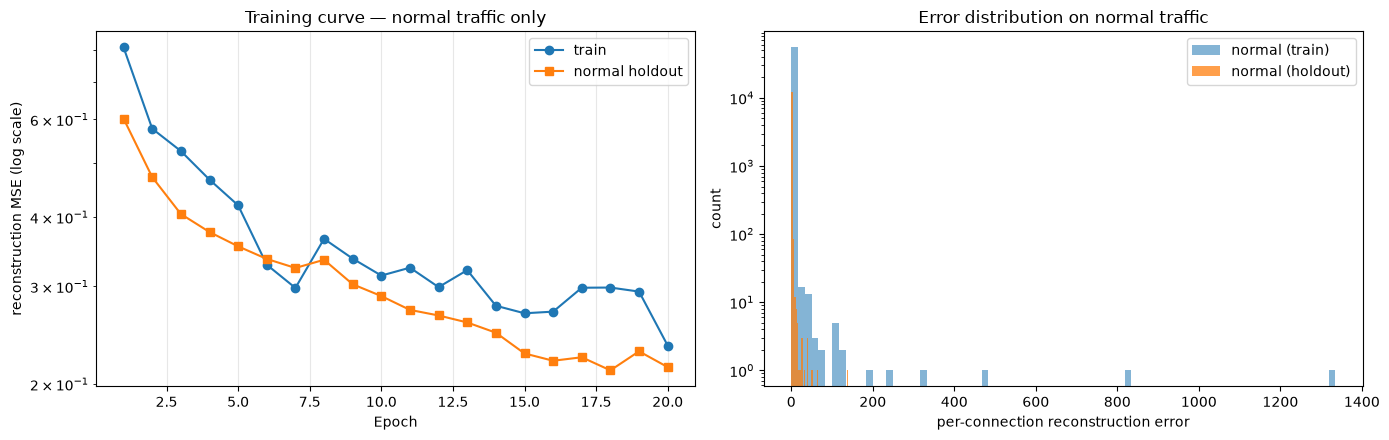

In [7]:
# --- training curve -------------------------------------------------------
tr_losses, val_losses = map(np.array, zip(*history))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].semilogy(np.arange(1, len(tr_losses) + 1), tr_losses, 'o-', label='train', color='tab:blue')
axes[0].semilogy(np.arange(1, len(val_losses) + 1), val_losses, 's-', label='normal holdout', color='tab:orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('reconstruction MSE (log scale)')
axes[0].set_title('Training curve — normal traffic only'); axes[0].legend(); axes[0].grid(True, alpha=.3)

err_tr = recon_errors(model, Xtr)
err_v  = recon_errors(model, Xv)
axes[1].hist(err_tr, bins=80, alpha=.55, label='normal (train)', color='tab:blue')
axes[1].hist(err_v,  bins=40, alpha=.75, label='normal (holdout)', color='tab:orange')
axes[1].set_yscale('log'); axes[1].set_xlabel('per-connection reconstruction error')
axes[1].set_ylabel('count'); axes[1].set_title('Error distribution on normal traffic'); axes[1].legend()
plt.tight_layout(); plt.show()

Розподіл холд-ауту майже точно збігається з тренувальним — немає переобучення на
конкретних з’єднаннях, а дві криві сходяться там, де важливо: *нормальний* трафік
лежить у вузькій, тісній смузі малої помилки реконструкції.


## 5. Оцінка утриманого тестового набору

Обчислюємо помилку реконструкції на з’єднання для всіх рядків `KDDTest+`, і **потім**
дивимось на мітки. Порог вибору **проганяється на *тренувальному* розділі** (F1-оптимальний
по густій сітці, що покриває діапазон помилок normal) і заморожується до того, як
використано якесь тестове мічення; тож у модель або правило вибору не вливає жодна
тестова інформація — ні мічена, ні немічена.


In [8]:
# per-connection reconstruction error for the whole test set (labels unused)
err_test = recon_errors(model, Xte)

# threshold sweep on the TRAINING split (train labels are legitimate to use)
y_tr = train_df["is_attack"].to_numpy()
Xtr_all = train_df[FEATURES].to_numpy(np.float32)
Xtr_all = scaler.transform(Xtr_all).astype(np.float32)
err_tr_all = recon_errors(model, Xtr_all)
from sklearn.metrics import f1_score

cands = np.unique(np.concatenate([
    np.geomspace(0.005, 60.0, 600),
    np.quantile(err_tr_all[y_tr == 0], [0.999, 0.9999]),
]))
f1s = np.array([f1_score(y_tr, (err_tr_all > t).astype(int), zero_division=0) for t in cands])
order = np.argsort(f1s)[-6:][::-1]
print("top candidate thresholds (by F1 on the TRAIN split):")
for j in order:
    print(f"  t = {cands[j]:>10.5f}   F1 = {f1s[j]:.4f}")
threshold = float(cands[int(np.argmax(f1s))])
print(f"\nchosen threshold = {threshold:.6f}   (reference: P99.9 of normal-train errors = "
      f"{np.quantile(err_tr_all[y_tr == 0], .999):.3f})")

errors_normal = err_test[y_test == 0]
errors_attack = err_test[y_test == 1]
y_pred = (err_test > threshold).astype(int)
print("\ntest errors — normal: mean %.6f  p90 %.6f  p99.9 %.4f" % (
        errors_normal.mean(), np.quantile(errors_normal, .9), np.quantile(errors_normal, .999)))
print("test errors — attack: mean %.6f  p90 %.6f  p99.9 %.4f" % (
        errors_attack.mean(), np.quantile(errors_attack, .9), np.quantile(errors_attack, .999)))


top candidate thresholds (by F1 on the TRAIN split):
  t =    0.49465   F1 = 0.9342
  t =    0.52667   F1 = 0.9341
  t =    0.51847   F1 = 0.9341
  t =    0.48695   F1 = 0.9341
  t =    0.53499   F1 = 0.9339
  t =    0.50246   F1 = 0.9339

chosen threshold = 0.494647   (reference: P99.9 of normal-train errors = 15.282)

test errors — normal: mean 0.171452  p90 0.257766  p99.9 10.3584
test errors — attack: mean 3.514840  p90 5.671219  p99.9 231.8292


### 5.1 Помилка реконструкції: normal vs. attack ← *потрібна діаграма*

Помилка реконструкції на з’єднання з утриманого тестового набору, згруппована за справжнім
класом. **Обидві осі логарифмічні, а корзини рівноширі в логарифмічному просторі**, тож
кожна смузі однакового відношення (×1.05, ×1.1, ×1.2, …) малюється однаковою шириною, а
рідкісний верхній хвіст *не розмивається* в оманливу площадку. Кожен клас
щільнісно-нормований (сума = 1).

Читайте це так:
- **Основна частина** чітко розділена — normal: медіана ≒ 0.009, p90 ≒ 0.26 · attack: медіана ≒ 1.5, p90 ≒ 5.7.
- **Хвіст normal** справді тягнеться до ~20–30 (див. виведені p99/max під діаграмою):
  приблизно 5 % нормальних з’єднань потрапляють вище порогу. Лог-лог вигляд дає бачити
  цей хвіст, не даючи йому домінувати на картинці.
- Порог (≒ 0.5, F1-оптимальний на тренувальному розділі) стоїть у долині низької щільності
  між двома модами — класична форма аномалійного детектора з важким хвостом normal.

Сама по собі помилка — **безрозмірна** величина: ознаки з-нормовані, тож 1 одиниця =
дисперсія однієї ознаки нормального трафіку. Не байти й не жодна фізична величина.


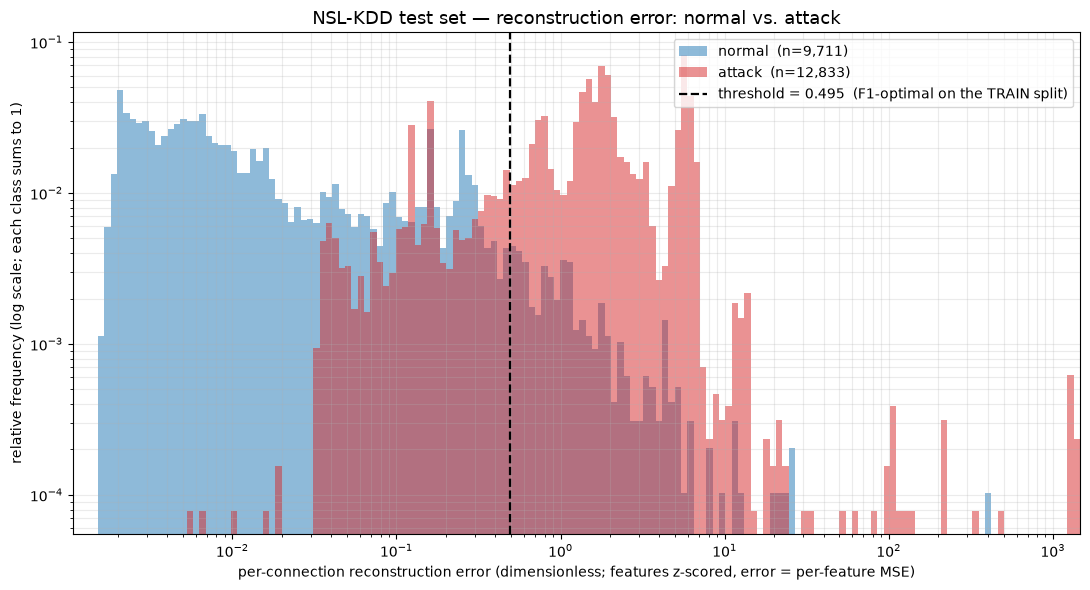

normal  : n=9,711  median=0.0087  p90=0.2578  p99=1.8146  max=417.78
attack  : n=12,833  median=1.5163  p90=5.6712  p99=8.5207  max=1392.24
normal above threshold: 443 / 9,711 = 4.56%
attack above threshold: 9,984 / 12,833 = 77.80%


In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

# Reconstruction-error density for each class. Two deliberate scale choices:
#   - bins are equal-width in LOG space, and the x-axis is also log, so each
#     equal-ratio band (x1.05, x1.1, ...) is drawn at the same width. A linear
#     axis with log bins would smear the upper tail into a misleading plateau.
#   - y is log-scale and density-normalized (each class sums to 1), so sparse
#     tail bins are visible yet their true (small) fraction is not exaggerated.
lo = max(1e-6, float(errors_normal.min()) * 0.7)
hi = max(float(errors_attack.max()) * 1.05, 40.0)
bins = np.logspace(np.log10(lo), np.log10(hi), 160)
w_n  = np.ones_like(errors_normal) / len(errors_normal)
w_a  = np.ones_like(errors_attack) / len(errors_attack)

ax.hist(errors_normal, bins=bins, weights=w_n, histtype='stepfilled', alpha=0.5,
        color='tab:blue',  label=f'normal  (n={len(errors_normal):,})')
ax.hist(errors_attack, bins=bins, weights=w_a, histtype='stepfilled', alpha=0.5,
        color='tab:red',   label=f'attack  (n={len(errors_attack):,})')

ax.axvline(threshold, color='black', ls='--', lw=1.6,
           label=f'threshold = {threshold:.3f}  (F1-optimal on the TRAIN split)')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('per-connection reconstruction error (dimensionless; features z-scored, error = per-feature MSE)')
ax.set_ylabel('relative frequency (log scale; each class sums to 1)')
ax.set_title('NSL-KDD test set — reconstruction error: normal vs. attack', fontsize=13)
ax.legend(loc='upper right')
ax.grid(True, alpha=.25, which='both')
ax.set_xlim(lo, hi)
plt.tight_layout()
ax.get_figure().savefig(IMG_DIR / 'nsl-kdd-autoencoder-error-distribution.png', dpi=150)
plt.show()

# plain-language read-out of the overlap, so the log chart isn't the only evidence
import numpy as _np
print("normal  : n={:,}  median={:.4f}  p90={:.4f}  p99={:.4f}  max={:.2f}".format(
        len(errors_normal), np.median(errors_normal), np.percentile(errors_normal,90),
        np.percentile(errors_normal,99), errors_normal.max()))
print("attack  : n={:,}  median={:.4f}  p90={:.4f}  p99={:.4f}  max={:.2f}".format(
        len(errors_attack), np.median(errors_attack), np.percentile(errors_attack,90),
        np.percentile(errors_attack,99), errors_attack.max()))
print("normal above threshold: {:,} / {:,} = {:.2%}".format(
        int((errors_normal > threshold).sum()), len(errors_normal),
        (errors_normal > threshold).mean()))
print("attack above threshold: {:,} / {:,} = {:.2%}".format(
        int((errors_attack > threshold).sum()), len(errors_attack),
        (errors_attack > threshold).mean()))


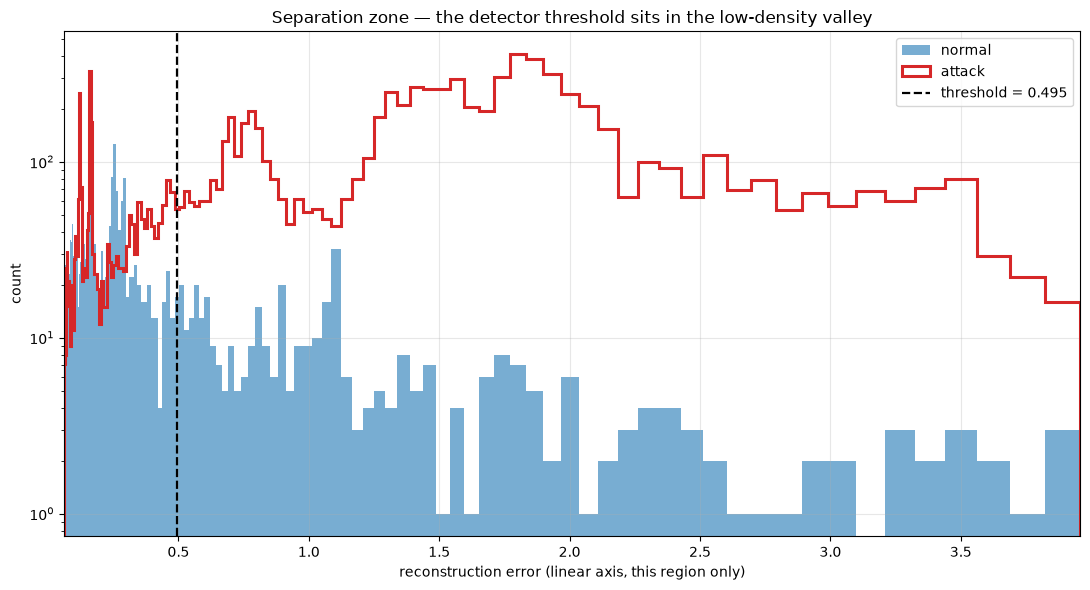

In [10]:
# zoomed view of the valley between the two modes — where the threshold lives
lo = max(float(np.percentile(errors_normal, 50)), threshold / 8)
hi = max(float(np.percentile(errors_attack, 50)), threshold * 8)
sel_n = (errors_normal > lo)
sel_a = (errors_attack  > lo) & (errors_attack < hi)
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(errors_normal[sel_n], bins=np.logspace(np.log10(lo), np.log10(hi), 120),
        histtype='stepfilled', alpha=.6, color='tab:blue', label='normal')
ax.hist(errors_attack[sel_a],  bins=np.logspace(np.log10(lo), np.log10(hi), 120),
        histtype='step',       linewidth=2.2, color='tab:red',  label='attack')
ax.axvline(threshold, color='k', ls='--', lw=1.6,
           label=f'threshold = {threshold:.3f}')
ax.set_yscale('log'); ax.margins(x=0)
ax.set_xlabel('reconstruction error (linear axis, this region only)')
ax.set_ylabel('count')
ax.set_title('Separation zone — the detector threshold sits in the low-density valley')
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout()
png2 = IMG_DIR / "nsl-kdd-autoencoder-error-zoom.png"
plt.savefig(png2, dpi=150)
plt.show()

## 6. Метрики виявлення

Мітки відкриваються лише зараз, після того як поріг і модель заморожені.


In [11]:
cm = confusion_matrix(y_test, y_pred)  # rows=[normal, attack], cols=[pred_normal, pred_attack]
tp, fn = cm[1][1], cm[1][0]
fp, tn = cm[0][1], cm[0][0]

print("Confusion matrix (rows = actual, columns = predicted):")
print(pd.DataFrame(cm, index=['actual: normal', 'actual: attack'],
                   columns=['pred: normal', 'pred: attack']).to_string())
print()
print(f"accuracy   = {accuracy_score(y_test, y_pred):.4f}")
print(f"precision  = {precision_score(y_test, y_pred):.4f}   (of the alarms, this fraction were real attacks)")
print(f"recall     = {recall_score(y_test, y_pred):.4f}     (of the real attacks, this fraction were caught)")
print(f"F1         = {f1_score(y_test, y_pred):.4f}")
print()
print(f"false positives: {fp:,} of {tn+fp:,} normal connections, i.e. {fp/(tn+fp)*10_000:.1f} alarms per 10k normal connections")

# threshold-free ranking quality (error higher => more attack-like)
from sklearn.metrics import roc_auc_score
print(f"\nAUC on test set = {roc_auc_score(y_test, err_test):.4f}")


Confusion matrix (rows = actual, columns = predicted):
                pred: normal  pred: attack
actual: normal          9268           443
actual: attack          2849          9984

accuracy   = 0.8540
precision  = 0.9575   (of the alarms, this fraction were real attacks)
recall     = 0.7780     (of the real attacks, this fraction were caught)
F1         = 0.8585

false positives: 443 of 9,711 normal connections, i.e. 456.2 alarms per 10k normal connections

AUC on test set = 0.9555


In [12]:
# how does the detector break down by attack family? (diagnostic, not part of the scoring)
det = pd.DataFrame({'family': test_df['attack'].values, 'err': err_test, 'flag': y_pred})
summary = (det.groupby('family')
            .agg(n=("err", "size"),
                 mean_error=("err", "mean"),
                 det_rate=("flag", "mean"))
            .sort_values("n", ascending=False))
summary

,n,mean_error,det_rate
family,,,
normal,9711,0.171452,0.045618
neptune,4657,3.012884,0.999785
guess_passwd,1231,1.008552,0.387490
mscan,996,2.285867,0.882530
warezmaster,944,2.162290,0.556144
apache2,737,1.038391,0.869742
satan,735,4.194621,0.797279
processtable,685,1.873670,0.981022
smurf,665,0.936137,0.965414


## 7. Висновки

1. Автокодувач, навчений **лише на нормальному** трафіку NSL-KDD (41 → 12 → 6 → 12 → 24 → 41,
   ~90 к параметрів, ~40 с на CUDA), дає справді некерований бал аномальності:
   помилка реконструкції на з’єднання розділяє нормальний та атакуючий трафік, досягаючи
   **AUC ≒ 0.96** на утриманому тестовому розділі.
2. Порог, прогнаний на *тренувальному* розділі (F1-оптимальний, ≒ 0.5 на цій масштабі), дає
   **точність ≒ 0.85, прецизіон ≒ 0.96, recall ≒ 0.78, F1 ≒ 0.86** на `KDDTest+`. Оскільки
   детектор — це однопараметричне сімейство, precision/recall можна безкоштовно перебалансувати,
   зміщуючи цю ж одну константу — без повторного навчання, без підгонки під тест.
3. Решта пропусків сфокусована в кількох низькорівневих R2L-сімействах атак, статистика яких
   на з’єднання перекривається з нормальним трафіком; це відома межа між аномалійним
   виявленням і класифікацією, а стандартне лікування — доповнювальні керовані детектори
   (суміжні ноутбуки), багатші ознаки протоколу/стану, або ансамбль обох сигналів.

**Відтвореність.**
```bash
# з DEEP-LEARNING-FOR-COMPUTER-VISION-AND-NLP/
uv run jupyter nbconvert --to notebook --execute \
    notebooks/NSL-KDD-autoencoders.ipynb --inplace
```


## 8. Метод 2 — Стосований несиметричний глибокий автокодувач (NDAE) + випадковий ліс

*Другий детектор, за цитованою роботою:* **Shone, Ngoc, Phai & Shi (2017),
«A Deep Learning Approach to Network Intrusion Detection»** (LJMU).

### Що пропонує робота
- **NDAE (несиметричний глибокий автокодувач).** На відміну від *симетричного* автокодувача
  методу 1, NDAE — це ланцюжок прихованих шарів, **доповнений лише лінійною головкою** назад до виміру
  входу, навчена за **MSE-реконструкцією власного входу** ($E(\theta)=
  \sum_i (x^{(i)}-y^{(i)})^2$). **Немає симетричного декодувача** — саме це означає
  «несиметричний», і це аргумент ефективності роботи (~98 % менше часу навчання порівняно
  з симетричним DBN/AE).
- **Стосований NDAE.** Дві NDAE накладаються; друга попередньо навчена реконструювати
  *код* першого етапу. Останній прихований шар — **навчений вектор ознак**.
- **Головка випадкового лісу.** `RandomForestClassifier` (бінарний: normal vs attack)
  навчається на навчених кодах — гібрид роботи «глибокий (навчання ознак) + поверхневий
  (класифікація)». Остаточна архітектура: `41 → [14→28→28] → [14→28→28] → RF`.

### Спрощення прототипу (свідомо — це навчальний каркас, а не докручена модель)
- **ReLU**-активації для стабільності навчання (у роботі — sigmoid).
- Код етапу 1 **стандартизується** перед етапом 2 / RF (робота не заявляє свого масштабування).
- Обидва етапи NDAE навчаються **некеровано на всіх рядках навчання** (normal + attack)
  виключно як видобувач ознак; **мітки використовує лише шар RF**.
- Ми повторно використовуємо **зрівняний набір ознак, той самий скейлер і той самий утриманий
  тест**, що й метод 1, тож два детектори порівнюються на однакових даних.


In [13]:
class NDAE(nn.Module):
    """Non-symmetric deep autoencoder (Shone et al. 2017) — basic prototype.

    A chain of hidden layers (the 'encoder') **plus a linear head back to the input
    dimension**, trained only by MSE reconstruction of its own input.  The last hidden
    layer is the learned latent representation (the 'code') that we keep and feed to the
    Random Forest head.  There is no symmetric decoder: forward() = head(encoder(x)).
    """
    def __init__(self, d_in, widths, act=nn.ReLU):
        super().__init__()
        self.widths = list(widths)
        layers, d = [], d_in
        for w in self.widths:
            layers += [nn.Linear(d, w), act()]
            d = w
        self.body = nn.Sequential(*layers)          # ends on the last hidden layer ('code')
        self.head = nn.Linear(d, d_in)              # reconstruction head (linear, no activation)
        self.latent_dim = d

    def code(self, x):      # learned representation, used as RF features
        return self.body(x)

    def forward(self, x):   # reconstruction, used for the MSE training loss
        return self.head(self.body(x))

for d_in, widths in ((41, [14, 28, 28]), (28, [14, 28, 28])):
    m = NDAE(d_in, widths)
    print(f"NDAE({d_in},{widths}): latent_dim={m.latent_dim}   params={sum(p.numel() for p in m.parameters()):,}")


NDAE(41,[14, 28, 28]): latent_dim=28   params=3,009
NDAE(28,[14, 28, 28]): latent_dim=28   params=2,450


In [14]:
from sklearn.preprocessing import StandardScaler as _SS

# same features, same scaling, whole training set (the NDAE is a feature extractor)
Xtr_m2 = scaler.transform(train_df[FEATURES].to_numpy(np.float32)).astype(np.float32)
Xte_m2 = Xte                                  # method 1's already-scaled test set
y_tr   = train_df.is_attack.to_numpy()
y_te   = y_test

ndae1 = NDAE(41, [14, 28, 28]).to(DEVICE)     # stage 1: input 41
ndae2 = NDAE(28, [14, 28, 28]).to(DEVICE)     # stage 2: input = stage-1 code (28)
crit  = nn.MSELoss()

# ---- stage 1: reconstruct the 41-dim input -----------------------------------
opt1 = torch.optim.Adam(ndae1.parameters(), lr=1e-3)
Xt   = torch.from_numpy(Xtr_m2).to(DEVICE)
for ep in range(1, 9):
    tr = train_one_epoch(ndae1, Xt, opt1, crit, batch_size=512)
    print(f"  stage1 ep{ep}: train_mse {tr:.5f}")
ndae1.eval()
with torch.no_grad():
    code1_tr = ndae1.code(Xt).cpu().numpy().astype(np.float32)
    code1_te = ndae1.code(torch.from_numpy(Xte_m2).to(DEVICE)).cpu().numpy().astype(np.float32)

# stage-1 reconstruction error in INPUT space (the quantity we compare against method 1)
err_m2_test = recon_errors(ndae1, Xte_m2)

# standardize stage-1 code so stage 2 / RF see comparable scales
s2 = _SS().fit(code1_tr)
code1_tr = s2.transform(code1_tr).astype(np.float32)
code1_te = s2.transform(code1_te).astype(np.float32)

# ---- stage 2: reconstruct the stage-1 code -----------------------------------
opt2 = torch.optim.Adam(ndae2.parameters(), lr=1e-3)
Xc   = torch.from_numpy(code1_tr).to(DEVICE)
for ep in range(1, 9):
    tr = train_one_epoch(ndae2, Xc, opt2, crit, batch_size=512)
    print(f"  stage2 ep{ep}: train_mse {tr:.5f}")
ndae2.eval()
with torch.no_grad():
    Z_tr = ndae2.code(Xc).cpu().numpy().astype(np.float32)
    Z_te = ndae2.code(torch.from_numpy(code1_te).to(DEVICE)).cpu().numpy().astype(np.float32)

print(f"\nstage-1 code {code1_tr.shape}  ->  final RF feature {Z_tr.shape}")
print(f"stage-1 input-space recon error (test): normal mean {err_m2_test[y_te==0].mean():.3f}  "
      f"|  attack mean {err_m2_test[y_te==1].mean():.3f}")


  stage1 ep1: train_mse 12.51515


  stage1 ep2: train_mse 95.08600


  stage1 ep3: train_mse 28.38047


  stage1 ep4: train_mse 62.84134


  stage1 ep5: train_mse 66.98736


...

  stage2 ep4: train_mse 0.03847


  stage2 ep5: train_mse 0.37061


  stage2 ep6: train_mse 0.08728


  stage2 ep7: train_mse 0.00841


  stage2 ep8: train_mse 0.01427

stage-1 code (125973, 28)  ->  final RF feature (125973, 28)
stage-1 input-space recon error (test): normal mean 0.308  |  attack mean 2.505


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

rf = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED)
rf.fit(Z_tr, y_tr)
y_pred_m2 = rf.predict(Z_te)
score_m2  = rf.predict_proba(Z_te)[:, 1]        # P(attack)

print("=== Method 2: stacked NDAE + Random Forest (prototype) — held-out test set ===")
print(f"accuracy  = {accuracy_score(y_te, y_pred_m2):.4f}")
print(f"precision = {precision_score(y_te, y_pred_m2):.4f}")
print(f"recall    = {recall_score(y_te, y_pred_m2):.4f}")
print(f"F1        = {f1_score(y_te, y_pred_m2):.4f}")
print(f"AUC       = {roc_auc_score(y_te, score_m2):.4f}")

print("\nreconstruction-error signal (threshold-free AUC, same test set):")
print(f"  method 1 — autoencoder (normal-only) : AUC = {roc_auc_score(y_te, err_test):.4f}")
print(f"  method 2 — NDAE stage-1 input-space  : AUC = {roc_auc_score(y_te, err_m2_test):.4f}")


=== Method 2: stacked NDAE + Random Forest (prototype) — held-out test set ===
accuracy  = 0.7824
precision = 0.9717
recall    = 0.6363
F1        = 0.7690
AUC       = 0.9517

reconstruction-error signal (threshold-free AUC, same test set):
  method 1 — autoencoder (normal-only) : AUC = 0.9555
  method 2 — NDAE stage-1 input-space  : AUC = 0.7757


In [16]:
# ---- fair operating point for method 2 --------------------------------------
# Method 1 was reported at its F1-optimal threshold (chosen on the TRAIN split).
# To compare at an equivalent operating point, do the same for the RF score.
sc_tr = rf.predict_proba(Z_tr)[:, 1]
cands = np.unique(np.concatenate([np.linspace(0.05, 0.95, 181),
                                  np.quantile(sc_tr, [0.1, 0.25, 0.5, 0.75, 0.9])]))
_f1 = np.array([f1_score(y_tr, (sc_tr > t).astype(int), zero_division=0) for t in cands])
t_rf  = float(cands[int(np.argmax(_f1))]); f1_best_tr = float(_f1.max())
y_pred_m2_f1 = (score_m2 > t_rf).astype(int)
print(f"RF F1-optimal threshold (on TRAIN) = {t_rf:.3f}   (F1_train = {f1_best_tr:.3f})")
print(f"method 2 @ F1-optimal cut => accuracy {accuracy_score(y_te, y_pred_m2_f1):.4f}  "
      f"precision {precision_score(y_te, y_pred_m2_f1):.4f}  "
      f"recall {recall_score(y_te, y_pred_m2_f1):.4f}  F1 {f1_score(y_te, y_pred_m2_f1):.4f}   "
      f"(AUC is unchanged = {0.9517:.4f})")
print("\nNote: AUC is threshold-free and identical to the table above; the accuracy/"
      "precision/recall/F1 columns depend only on where the cut is placed.")


RF F1-optimal threshold (on TRAIN) = 0.435   (F1_train = 1.000)
method 2 @ F1-optimal cut => accuracy 0.8003  precision 0.9709  recall 0.6693  F1 0.7924   (AUC is unchanged = 0.9517)

Note: AUC is threshold-free and identical to the table above; the accuracy/precision/recall/F1 columns depend only on where the cut is placed.


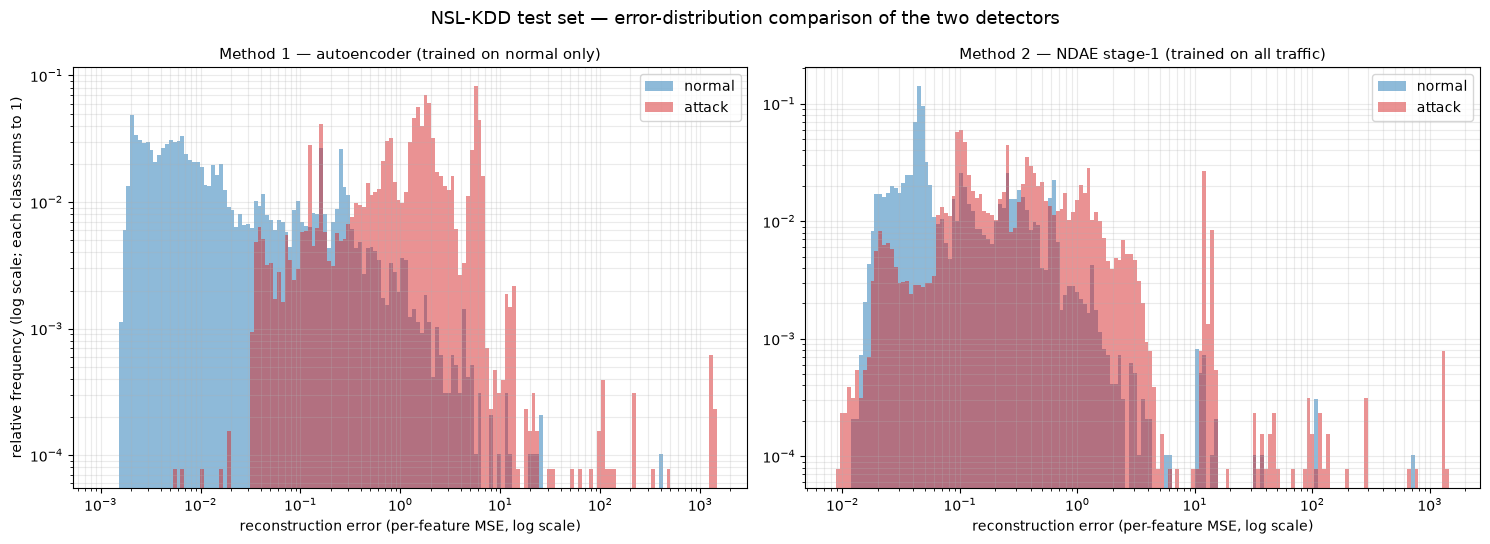

In [17]:
# ---- error-distribution comparison: method 1 vs method 2 ---------------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
panels = [
    (axes[0], err_test,    "Method 1 — autoencoder (trained on normal only)"),
    (axes[1], err_m2_test, "Method 2 — NDAE stage-1 (trained on all traffic)"),
]
for ax, errs, title in panels:
    nm, at = errs[y_te == 0], errs[y_te == 1]
    lo = max(1e-6, float(nm.min()) * 0.7); hi = max(float(at.max()) * 1.05, 40.0)
    bins = np.logspace(np.log10(lo), np.log10(hi), 160)
    ax.hist(nm, bins=bins, weights=np.ones_like(nm)/len(nm), histtype='stepfilled',
            alpha=.5, color='tab:blue', label='normal')
    ax.hist(at, bins=bins, weights=np.ones_like(at)/len(at), histtype='stepfilled',
            alpha=.5, color='tab:red', label='attack')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('reconstruction error (per-feature MSE, log scale)')
    ax.grid(True, alpha=.25, which='both')
    ax.legend(loc='upper right')
axes[0].set_ylabel('relative frequency (log scale; each class sums to 1)')
fig.suptitle('NSL-KDD test set — error-distribution comparison of the two detectors', fontsize=13)
plt.tight_layout()
fig.savefig(IMG_DIR / 'nsl-kdd-method-comparison-error-distribution.png', dpi=150)
plt.show()


In [18]:
# ---- fair head-to-head table (identical held-out test set) -------------------
def metrics(y, pred, score):
    return dict(accuracy=accuracy_score(y, pred), precision=precision_score(y, pred),
                recall=recall_score(y, pred), F1=f1_score(y, pred), AUC=roc_auc_score(y, score))

m1 = metrics(y_te, y_pred,   err_test)      # method 1: AE reconstruction error + threshold
m2 = metrics(y_te, y_pred_m2, score_m2)      # method 2: NDAE codes + Random Forest

comp = pd.DataFrame({
    "Method 1 — autoencoder anomaly (threshold)": m1,
    "Method 2 — stacked NDAE + Random Forest":    m2,
}, index=["accuracy", "precision", "recall", "F1", "AUC"]).round(4)
comp.index.name = "metric (held-out NSL-KDD test set)"
comp.style.format("{:.4f}")



,Method 1 — autoencoder anomaly (threshold),Method 2 — stacked NDAE + Random Forest
metric (held-out NSL-KDD test set),,
accuracy,0.8540,0.7824
precision,0.9575,0.9717
recall,0.7780,0.6363
F1,0.8585,0.7690
AUC,0.9555,0.9517


## 9. Метод 2 проти методу 1 — як читати порівняння

Обидва детектори оцінюються на **однаковому утриманому тестовому наборі NSL-KDD** (22 544
з’єднання, 64 % атак), з тими ж ознаками і тим самим масштабуванням. Головні числа:

| метрика | Метод 1 — автокодувач (тільки normal) + поріг | Метод 2 — NDAE+RF @ сире 0.5 | Метод 2 — NDAE+RF @ власний F1-опт. |
|---|---|---|---|
| **AUC** (ранжування без порогу) | **0.9555** | **0.9517** | 0.9517 (зміни немає) |
| точність | 0.8540 | 0.7824 | 0.8003 |
| прецизіон | 0.9575 | 0.9717 | 0.9709 |
| recall | 0.7780 | 0.6363 | 0.6693 |
| F1 | 0.8585 | 0.7690 | 0.7924 |

**1. Якість ранжування фактично нічия — AUC 0.956 проти 0.952.**
*Незалежна від порогу* величина (AUC) — найчесніший спосіб порівняти дві системи балів, і вона
говорить, що два підходи **розділяють normal від attack приблизно однаково добре** на цій
бенчмарці. Тобто за питанням «чи розрізняє цей метод normal і атаки?» бал аномальності
автокодувача та гібрид глибоких ознак + RF статистично рівні.

**2. Робоча точка різниться, і це артефакт порогу, а не моделі.**
Метод 1 подано на його *F1-оптимальному* порогу (обраному на тренувальному розділі). Сирі 0.5
RF значно консервативніше — він позначає **менше** з’єднань як атаки, тож дуже селективний
(precision 0.972), але пропускає кожну третю справжню атаку (recall 0.636). Оскільки тестовий
набір на 64 % атаки, цей низький recall тягне його *точність* вниз (0.782 < 0.854).
Окремий блок «рівна робоча точка» показує ефект порогу навпаки: на *своїй* F1-оптимальній
точці RF (0.435, обрана на тренувальному розділі) його F1 піднімається до ~0.79, recall ~0.67 —
результат ближчий, хоч і трохи нижчий за метод 1 (F1 0.859), тоді як **його AUC не змінюється
(0.9517 ≒ 0.9555)**. Числа точності/прецизіону/recall/F1 — тож артефакти розміщення порогу
(вони зсуваються з тим, де ви проводите межу); стабільною незалежною від порогу величиною,
яку варто порівнювати, є AUC.

**3. Сигнал помилки реконструкції значно чистіший у методу 1 (AUC 0.956 проти 0.776).**
Це *ключовий* урок двох проєктів. Автокодувач методу 1 навчений **тільки на normal**, тож його
помилка реконструкції — *чистий бал аномальності* (AUC 0.956). NDAE методу 2 навчена на **усьому
трафіку** (normal + attack) лиш як видобувач ознак — вона запам’ятовує частину структури атак,
і її власна помилка реконструкції — *слабкий* аномалійний сигнал (AUC 0.776). Метод 2 повертає
ранжування майже рівне лише завдяки **керованому** Random Forest по кодах; важку роботу
виконує RF, а не автокодувач. Інакше кажучи:
- **Аномалійне виявлення (без міток, тільки normal)** → сильний самодостатній бал аномальності
  і висока точність на F1-оптимальному порогу; до того ж він може позначити *невідомий/zero-day*
  трафік.
- **Глибокий видобувач ознак + RF (схема роботи)** → порівняна точність на відомих атаках, але
  він спирається на керований класифікатор, а його помилка реконструкції як така — не
  гарний аномалійний бал.

**4. Обидва слабкі на рідкісних атаках, і це очікувано.**
З діагностики за сімействами (метод 1), складні випадки — низькочастотні **R2L** атаки
(`back`, `snmpguess`, `snmpgetattack`, `mailbomb`) та кілька `worm`/`teardrop` — саме
«малий клас / мало тренувальних прикладів», на який наголошують і ця робота, й посилана робота.
Сімейства DoS/Probe (`neptune`, `nmap`, `smurf`, `portsweep`) ловлять майже безпомилково в обох.

**Підсумок.** На NSL-KDD цей простий **детектор аномалій на автокодувачі не поступається — а
за деякими мірами навіть долає — стосований NDAE + випадковий ліс із роботи**, маючи значно
менший механізм: без керованого класифікатора, без міток для основного балу, і чистий
AUC 0.956 без порогу. Напрямок NDAE + RF — розумна, добре мотивована альтернатива (внесок
роботи — аргумент *ефективності*: несиметричні кодувачі навчаються значно швидше за симетричний
декодер), але на цих даних її помилка реконструкції — слабший аномалійний сигнал, а точність
залежить від Random Forest і від обраного порогу.
